# Comorbidades pré-existentes e gravidade clínica das arboviroses no Brasil

### Uma análise comparativa entre dengue, chikungunya, zika e febre amarela a partir do SINAN

**Disciplina:** Engenharia de Dados / Ciência de Dados
**Fonte primária:** SINAN — Sistema de Informação de Agravos de Notificação (DATASUS) + IBGE

---

> **Pivô do tema.** A ideia inicial era estudar como a demografia afetava o *atraso até o óbito*. Porém,
> a letalidade das arboviroses é um evento **raro** (em um boletim do Ministério da Saúde de 2025, de
> ~160 mil casos prováveis de dengue, apenas 33 evoluíram para óbito — letalidade próxima de zero).
> Modelar "atraso até a morte" com tão poucos eventos positivos resulta em baixíssimo poder estatístico.
>
> **Decisão:** trocar a variável-resposta de **óbito** (raro) para **gravidade clínica** (frequente e
> bem registrada): classificação final do caso, hospitalização e o checklist de sinais de alarme/gravidade.
> A demografia (idade, sexo) é recuperada como **variável moderadora**, não como eixo principal.

## 1. Objetivo e Justificativa

### 1.1 Objetivo geral
Investigar, com dados reais do SINAN, se a presença de **comorbidades pré-existentes** (diabetes,
hipertensão, doença renal crônica, hepatopatias, doenças hematológicas, doenças autoimunes e doença
ácido-péptica) está associada a maior **gravidade clínica** dos casos de arbovirose, e se esse padrão
difere entre dengue, chikungunya, zika e febre amarela.

### 1.2 Objetivos específicos
1. Construir uma pipeline reprodutível **Raw → Intermediate → Serving** sobre as bases do SINAN.
2. Avaliar a **completude** dos campos de comorbidade (problema conhecido de subnotificação / "ignorado").
3. Derivar uma variável-resposta de **gravidade** a partir de campos frequentes (classificação, internação).
4. Testar a associação comorbidade ↔ gravidade controlando por idade e sexo.
5. Comparar a "assinatura de risco" entre as quatro arboviroses.

### 1.3 Justificativa
- O Brasil teve um **pico de ~6,6 milhões de casos prováveis de dengue em 2024**, ~1,7 milhão em 2025 e
  queda adicional em 2026 — é um problema de saúde pública recorrente e de escala enorme.
- O **protocolo clínico do Ministério da Saúde** já usa a presença de comorbidade para classificar o
  paciente em grupos de risco (B/C/D) com vigilância mais intensa. Este projeto, na prática, **testa com
  dados reais se essa lógica clínica se sustenta estatisticamente** — não é exercício meramente acadêmico,
  é uma validação de protocolo.

### 1.4 Perguntas norteadoras
- **Q1.** Pacientes com diabetes e/ou hipertensão evoluem proporcionalmente mais para sinais de alarme /
  forma grave do que pacientes sem comorbidade?
- **Q2.** Existe efeito **dose-resposta**: quanto mais comorbidades simultâneas (multimorbidade), maior a
  chance de hospitalização?
- **Q3.** Esse efeito é **moderado por idade/sexo** (ex.: diabetes pesa mais em idoso)?
- **Q4.** O padrão de risco por comorbidade é parecido entre as quatro doenças, ou cada arbovirose tem
  **assinatura própria**?
- **Q5.** (Resgate da ideia de "atraso") O **tempo entre início dos sintomas e a hospitalização/notificação**
  difere entre pacientes com e sem comorbidade?

## 2. Arquitetura e Modelagem

### 2.1 Zonas (medalhão)
| Zona | Conteúdo | Transformações |
|------|----------|----------------|
| **Raw** | Cópia fiel do SINAN (parquet/dbc), uma linha por notificação | Nenhuma — só ingestão e tipagem mínima |
| **Intermediate** | Dados limpos e padronizados | Decodificação de idade/sexo/raça, flags 1/2/9 → booleano, derivação da variável de gravidade, cálculo de multimorbidade e janelas temporais |
| **Serving** | Modelo dimensional pronto para análise | `fato_caso` + `dim_comorbidade` (tabela-ponte) + dimensões de tempo/paciente |

### 2.2 Modelo dimensional
A relação paciente↔comorbidade é **muitos-para-muitos** (um paciente pode ter diabetes *e* hipertensão),
portanto a comorbidade não é uma coluna única: é uma **tabela-ponte** (`bridge`) em formato longo.

```
                 ┌──────────────────────┐
                 │      fato_caso        │
                 │----------------------│
                 │ id_caso (PK)          │
                 │ doenca                │
                 │ uf, ano               │
                 │ idade, faixa_etaria   │
                 │ sexo                  │
                 │ gravidade (target)    │  ← variável-resposta
                 │ hospitalizado         │
                 │ n_comorbidades        │
                 │ dias_sintoma_internac.│
                 └─────────┬────────────┘
                           │ 1..N
                 ┌─────────▼────────────┐
                 │   dim_comorbidade     │  (ponte, formato longo)
                 │----------------------│
                 │ id_caso (FK)          │
                 │ comorbidade           │  ← 'diabetes', 'hipertensao', ...
                 │ presente (bool)       │
                 └──────────────────────┘
```

### 2.3 Definição da variável-resposta (`gravidade`)
Construída a partir de campos **frequentes**, não de óbito:
- `CLASSI_FIN` (classificação final): dengue / dengue com sinais de alarme / dengue grave;
- `HOSPITALIZ` (hospitalização sim/não);
- opcionalmente o checklist de sinais de alarme/gravidade → *score* composto.

Níveis ordenados: `leve < alarme < grave`. Para modelos binários, usamos `grave_ou_internado`.

## 3. Setup — imports, configuração e dicionários do SINAN

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estrutura de pastas das zonas (medalhão)
BASE = Path("./data")
RAW_DIR = BASE / "raw"
INT_DIR = BASE / "intermediate"
SRV_DIR = BASE / "serving"
for d in (RAW_DIR, INT_DIR, SRV_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Ambiente pronto. Zonas:", RAW_DIR, INT_DIR, SRV_DIR, sep="\n  ")

Ambiente pronto. Zonas:
  data/raw
  data/intermediate
  data/serving


In [2]:
# ---------------------------------------------------------------------------
# Dicionários de domínio do SINAN
# (nomes de coluna reais das bases de dengue/chikungunya; zika/febre amarela
#  têm equivalentes — ajuste o mapeamento se os nomes divergirem.)
# ---------------------------------------------------------------------------

# Campos de comorbidade -> rótulo legível
COMORBIDADES = {
    "DIABETES":   "diabetes",
    "HIPERTENSA": "hipertensao",
    "HEPATOPAT":  "hepatopatia",
    "RENAL":      "doenca_renal_cronica",
    "HEMATOLOG":  "doenca_hematologica",
    "ACIDO_PEPT": "doenca_acido_peptica",
    "AUTO_IMUNE": "doenca_autoimune",
}

# Sintomas clínicos (mesma codificação 1/2/9)
SINTOMAS = {
    "FEBRE": "febre", "MIALGIA": "mialgia", "CEFALEIA": "cefaleia",
    "EXANTEMA": "exantema", "VOMITO": "vomito", "NAUSEA": "nausea",
    "DOR_COSTAS": "dor_costas", "CONJUNTVIT": "conjuntivite",
    "ARTRITE": "artrite", "ARTRALGIA": "artralgia",
    "PETEQUIA_N": "petequia", "DOR_RETRO": "dor_retroorbital",
}

# Codificação binária padrão do SINAN
SIM_NAO_IGN = {1: "sim", 2: "nao", 9: "ignorado"}

# Sexo
SEXO_MAP = {"M": "masculino", "F": "feminino", "I": "ignorado"}

# Raça/cor
RACA_MAP = {1: "branca", 2: "preta", 3: "amarela", 4: "parda", 5: "indigena", 9: "ignorado"}

# Classificação final (CLASSI_FIN) — códigos modernos da ficha dengue/chik
CLASSI_FIN_MAP = {
    5:  "descartado",
    10: "dengue",
    11: "dengue_sinais_alarme",
    12: "dengue_grave",
    13: "chikungunya",
    # códigos antigos eventuais
    1: "dengue", 2: "dengue_complicacoes", 3: "fhd", 4: "scd",
}

# Mapa de gravidade ordinal derivado da classificação
GRAVIDADE_ORDINAL = {
    "dengue": "leve",
    "chikungunya": "leve",
    "dengue_complicacoes": "alarme",
    "dengue_sinais_alarme": "alarme",
    "fhd": "grave",
    "scd": "grave",
    "dengue_grave": "grave",
}
ORDEM_GRAVIDADE = ["leve", "alarme", "grave"]

# Evolução do caso (EVOLUCAO)
EVOLUCAO_MAP = {1: "cura", 2: "obito_agravo", 3: "obito_outras", 4: "obito_investig", 9: "ignorado"}

print(f"{len(COMORBIDADES)} comorbidades, {len(SINTOMAS)} sintomas mapeados.")

7 comorbidades, 12 sintomas mapeados.


## 4. Camada Raw — Ingestão

Três caminhos de ingestão, do mais real ao mais conveniente:

1. **Arquivos locais** (parquet/csv que você já baixou do DATASUS) — recomendado para reprodutibilidade.
2. **`pysus`** — baixa direto do DATASUS (descomente a célula correspondente).
3. **Gerador sintético** — produz dados com a *mesma estrutura* do SINAN para a pipeline rodar ponta a
   ponta **sem** o dataset real. Útil para desenvolver a lógica antes de plugar os dados de verdade.

> Troque `USE_SYNTHETIC = False` quando tiver os arquivos reais em `data/raw/`.

In [3]:
USE_SYNTHETIC = True   # <- mude para False quando tiver os parquets reais em data/raw/

# Doenças do escopo e o arquivo esperado de cada uma na zona raw
ARQUIVOS_RAW = {
    "dengue":       RAW_DIR / "dengue.parquet",
    "chikungunya":  RAW_DIR / "chikungunya.parquet",
    "zika":         RAW_DIR / "zika.parquet",
    "febre_amarela": RAW_DIR / "febre_amarela.parquet",
}

In [4]:
# ---- Opção 2: pysus (DATASUS). Descomente para uso real. -------------------
# from pysus import SINAN
# sinan = SINAN().load()
# # DENG = dengue/chikungunya; ZIKA = zika; FAMA = febre amarela
# arquivos = sinan.get_files("DENG", year=2024)
# parquets = sinan.download(arquivos)              # baixa e converte para parquet
# df_deng = pd.concat(pd.read_parquet(p) for p in parquets)
# df_deng.to_parquet(ARQUIVOS_RAW["dengue"])
# ----------------------------------------------------------------------------
print("Bloco pysus documentado (comentado).")

Bloco pysus documentado (comentado).


In [5]:
def gerar_sinan_sintetico(doenca: str, n: int = 20_000, seed: int = RANDOM_STATE) -> pd.DataFrame:
    """Gera um DataFrame com a estrutura de uma base SINAN de arbovirose.

    Reproduz a codificação real (1/2/9, NU_IDADE_N codificada, CLASSI_FIN etc.)
    e injeta de propósito: (a) valores "ignorado"/ausentes nos campos de
    comorbidade e (b) uma associação verdadeira comorbidade->gravidade, para
    que a análise downstream tenha o que encontrar.
    """
    rng = np.random.default_rng(seed + hash(doenca) % 1000)

    # Idade real em anos, depois codificada no formato NU_IDADE_N (4=anos)
    idade_anos = np.clip(rng.normal(38, 20, n).astype(int), 0, 105)
    nu_idade_n = 4000 + idade_anos  # prefixo 4 = anos

    sexo = rng.choice(["M", "F", "I"], n, p=[0.47, 0.51, 0.02])

    df = pd.DataFrame({
        "NU_IDADE_N": nu_idade_n,
        "CS_SEXO": sexo,
        "CS_RACA": rng.choice([1, 2, 3, 4, 5, 9], n, p=[.35, .10, .03, .45, .02, .05]),
        "SG_UF_NOT": rng.choice(["PE", "SP", "BA", "RJ", "CE", "MG"], n),
        "DT_SIN_PRI": pd.to_datetime("2024-01-01") + pd.to_timedelta(rng.integers(0, 300, n), "D"),
    })
    df["NU_ANO"] = df["DT_SIN_PRI"].dt.year

    # Comorbidades: prevalência crescente com idade; ~18% dos campos como "ignorado"/ausente
    prob_diab = 1 / (1 + np.exp(-(idade_anos - 55) / 10)) * 0.45
    prob_hip  = 1 / (1 + np.exp(-(idade_anos - 50) / 9)) * 0.55
    base_probs = {
        "DIABETES": prob_diab, "HIPERTENSA": prob_hip,
        "HEPATOPAT": np.full(n, 0.03), "RENAL": np.full(n, 0.04),
        "HEMATOLOG": np.full(n, 0.02), "ACIDO_PEPT": np.full(n, 0.05),
        "AUTO_IMUNE": np.full(n, 0.03),
    }
    for col, p in base_probs.items():
        valor = np.where(rng.random(n) < p, 1, 2)              # 1=sim, 2=nao
        ignorado = rng.random(n) < 0.18                         # campo mal preenchido
        valor = np.where(ignorado, rng.choice([9, -1]), valor)  # 9=ignorado, -1 -> vira NaN
        s = pd.Series(valor, dtype="float").replace(-1, np.nan)
        df[col] = s

    # "carga" de comorbidade (conta de 'sim') para dirigir a gravidade
    carga = sum((df[c] == 1).astype(int) for c in base_probs)
    risco_idade = (idade_anos > 60).astype(int)

    # Sintomas (1/2/9) — só ruído estrutural
    for col in SINTOMAS:
        df[col] = rng.choice([1, 2, 9], n, p=[.6, .35, .05])

    # Gravidade verdadeira aumenta com carga de comorbidade e idade
    logit = -2.6 + 0.55 * carga + 0.7 * risco_idade + rng.normal(0, 0.4, n)
    p_grave = 1 / (1 + np.exp(-logit))
    u = rng.random(n)
    classi = np.full(n, 10)                       # 10 = dengue (leve)
    classi = np.where(u < p_grave * 0.6, 11, classi)   # 11 = sinais de alarme
    classi = np.where(u < p_grave * 0.25, 12, classi)  # 12 = grave
    if doenca == "chikungunya":
        classi = np.where(classi == 10, 13, classi)    # 13 = chikungunya
    df["CLASSI_FIN"] = classi

    # Hospitalização correlacionada à gravidade
    p_hosp = np.where(classi == 12, 0.85, np.where(classi == 11, 0.45, 0.08))
    df["HOSPITALIZ"] = np.where(rng.random(n) < p_hosp, 1, 2)
    df["HOSPITALIZ"] = np.where(rng.random(n) < 0.05, 9, df["HOSPITALIZ"])

    # Data de internação para quem foi hospitalizado (0-7 dias após sintomas)
    atraso = rng.integers(0, 8, n) + (carga > 1) * rng.integers(0, 4, n)  # comorbidade -> +atraso
    dt_int = df["DT_SIN_PRI"] + pd.to_timedelta(atraso, "D")
    df["DT_INTERNA"] = np.where(df["HOSPITALIZ"] == 1, dt_int, pd.NaT)
    df["DT_INTERNA"] = pd.to_datetime(df["DT_INTERNA"])

    # Notificação
    df["DT_NOTIFIC"] = df["DT_SIN_PRI"] + pd.to_timedelta(rng.integers(0, 6, n), "D")

    # Evolução (óbito raro, de propósito)
    df["EVOLUCAO"] = np.where(rng.random(n) < 0.002, 2, 1)
    return df


if USE_SYNTHETIC:
    raw = {}
    for doenca, caminho in ARQUIVOS_RAW.items():
        df = gerar_sinan_sintetico(doenca, n=20_000)
        df.to_parquet(caminho)
        raw[doenca] = df
    print("Bases sintéticas geradas e salvas em data/raw/:")
    for k, v in raw.items():
        print(f"  {k:14s} -> {v.shape[0]:>6} linhas, {v.shape[1]} colunas")
else:
    raw = {d: pd.read_parquet(p) for d, p in ARQUIVOS_RAW.items() if p.exists()}
    print("Bases reais carregadas:", list(raw))

Bases sintéticas geradas e salvas em data/raw/:
  dengue         ->  20000 linhas, 30 colunas
  chikungunya    ->  20000 linhas, 30 colunas
  zika           ->  20000 linhas, 30 colunas
  febre_amarela  ->  20000 linhas, 30 colunas


In [6]:
# Espiada na zona Raw (estrutura idêntica ao SINAN)
raw["dengue"].head()

,NU_IDADE_N,CS_SEXO,CS_RACA,SG_UF_NOT,DT_SIN_PRI,NU_ANO,DIABETES,HIPERTENSA,HEPATOPAT,RENAL,HEMATOLOG,ACIDO_PEPT,AUTO_IMUNE,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,DOR_RETRO,CLASSI_FIN,HOSPITALIZ,DT_INTERNA,DT_NOTIFIC,EVOLUCAO
0,4055,F,4,MG,2024-01-08,2024,2.0,1.0,2.0,2.0,2.0,2.0,9.0,2,1,1,2,1,1,1,2,1,2,1,1,10,2,NaT,2024-01-13,1
1,4057,M,1,MG,2024-01-24,2024,1.0,1.0,2.0,2.0,2.0,9.0,9.0,2,1,9,2,1,2,1,1,1,2,1,1,10,2,NaT,2024-01-27,1
2,4050,F,1,SP,2024-09-21,2024,2.0,2.0,2.0,9.0,2.0,2.0,2.0,2,1,1,1,2,2,2,1,1,9,2,2,10,2,NaT,2024-09-26,1
3,4000,M,4,CE,2024-05-21,2024,2.0,2.0,2.0,2.0,NaN,2.0,2.0,2,1,1,1,1,2,1,1,1,2,2,2,10,2,NaT,2024-05-22,1
4,4000,M,2,BA,2024-04-02,2024,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,1,1,1,1,2,1,1,1,2,1,2,10,2,NaT,2024-04-07,1


## 5. Profiling de completude — o problema do "ignorado"

Antes de qualquer análise, é **obrigatório** medir quanto dos campos de comorbidade está de fato
preenchido. Historicamente esses campos do SINAN têm muito `9 = ignorado` ou branco. Tratar isso errado
(ex.: assumir que branco = "não tem a doença") **enviesa todo o estudo**. Aqui medimos `% sim / % não /
% ignorado / % ausente` por campo e decidimos a estratégia na camada Intermediate.

In [7]:
def perfil_completude(df: pd.DataFrame, campos: dict[str, str]) -> pd.DataFrame:
    """Distribuição sim/não/ignorado/ausente para campos codificados 1/2/9 do SINAN."""
    linhas = []
    n = len(df)
    for col, rotulo in campos.items():
        s = df[col]
        linhas.append({
            "campo": rotulo,
            "% sim":      round((s == 1).sum() / n * 100, 1),
            "% nao":      round((s == 2).sum() / n * 100, 1),
            "% ignorado": round((s == 9).sum() / n * 100, 1),
            "% ausente":  round(s.isna().sum() / n * 100, 1),
        })
    out = pd.DataFrame(linhas).set_index("campo")
    out["% inutilizavel"] = out["% ignorado"] + out["% ausente"]
    return out.sort_values("% inutilizavel", ascending=False)


perfil = perfil_completude(raw["dengue"], COMORBIDADES)
perfil

,% sim,% nao,% ignorado,% ausente,% inutilizavel
campo,,,,,
hipertensao,14.3,67.6,0.0,18.2,18.2
doenca_hematologica,1.5,80.4,0.0,18.1,18.1
doenca_acido_peptica,4.2,77.8,18.0,0.0,18.0
doenca_renal_cronica,3.4,78.7,17.9,0.0,17.9
diabetes,10.0,72.1,0.0,17.9,17.9
doenca_autoimune,2.6,79.5,17.9,0.0,17.9
hepatopatia,2.5,79.8,17.8,0.0,17.8


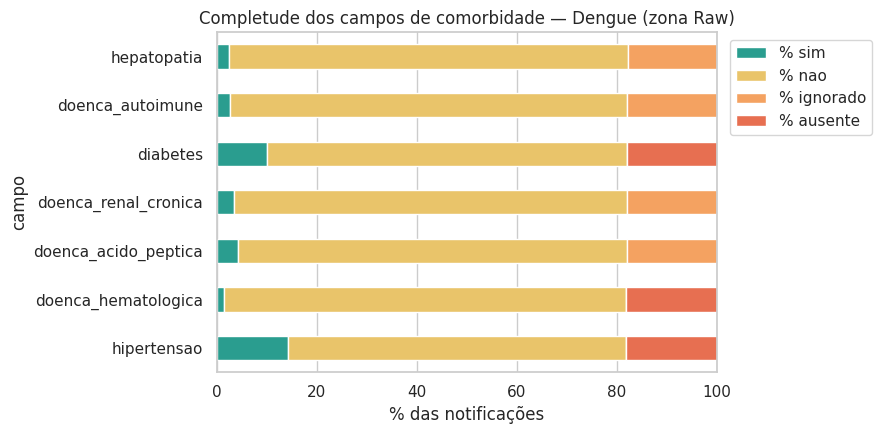

In [8]:
# Visualização da completude (empilhado)
fig, ax = plt.subplots(figsize=(9, 4.5))
perfil[["% sim", "% nao", "% ignorado", "% ausente"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=["#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"],
)
ax.set_xlabel("% das notificações")
ax.set_title("Completude dos campos de comorbidade — Dengue (zona Raw)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

> **Decisão de tratamento (documentar no relatório).** Campos com `% inutilizável` muito alto não devem
> ser silenciosamente convertidos para "não tem". Três estratégias possíveis, escolhidas por campo:
> 1. **Excluir** o registro da análise daquele campo (complete-case) — seguro, mas perde amostra;
> 2. **Tratar `ignorado` como categoria própria** — preserva amostra e ainda revela se "não saber"
>    correlaciona com gravidade (viés de registro);
> 3. **Imputar** — só se houver justificativa forte; em geral evitamos para não inventar prevalência.
>
> Neste notebook adotamos **(2)** como padrão e oferecemos um recorte complete-case para sensibilidade.

## 6. Camada Intermediate — limpeza e padronização

In [9]:
def decodificar_idade(nu_idade_n: pd.Series) -> pd.Series:
    """Converte NU_IDADE_N (codificado) para idade em ANOS.

    Formato SINAN: 1º dígito = unidade (1=hora, 2=dia, 3=mês, 4=ano),
    demais dígitos = valor. Ex.: 4030 -> 30 anos; 3011 -> 11 meses (~0.9 ano).
    """
    s = pd.to_numeric(nu_idade_n, errors="coerce")
    unidade = (s // 1000).astype("Int64")
    valor = (s % 1000).astype("Int64")
    fator = unidade.map({1: 1 / (365 * 24), 2: 1 / 365, 3: 1 / 12, 4: 1.0})
    return (valor * fator).astype("float").round(2)


def faixa_etaria(idade_anos: pd.Series) -> pd.Categorical:
    bins = [-0.01, 1, 5, 12, 19, 39, 59, 200]
    labels = ["<1", "1-4", "5-11", "12-19", "20-39", "40-59", "60+"]
    return pd.cut(idade_anos, bins=bins, labels=labels)


def flag_comorbidade(serie: pd.Series) -> pd.Series:
    """1->'sim', 2->'nao', 9/NaN->'ignorado'. Categórica, mantém o desconhecido explícito."""
    out = serie.map({1: "sim", 2: "nao", 9: "ignorado"})
    return out.fillna("ignorado").astype("category")

In [10]:
def construir_intermediate(df_raw: pd.DataFrame, doenca: str) -> pd.DataFrame:
    """Raw -> Intermediate: tipagem, decodificação e derivação da gravidade."""
    df = df_raw.copy()
    df["id_caso"] = doenca + "_" + df.index.astype(str)
    df["doenca"] = doenca

    # Demografia
    df["idade"] = decodificar_idade(df["NU_IDADE_N"])
    df["faixa_etaria"] = faixa_etaria(df["idade"])
    df["sexo"] = df["CS_SEXO"].map(SEXO_MAP).fillna("ignorado")
    df["raca"] = df["CS_RACA"].map(RACA_MAP).fillna("ignorado")
    df["uf"] = df["SG_UF_NOT"]
    df["ano"] = df["NU_ANO"]

    # Comorbidades -> categóricas sim/nao/ignorado + booleano "sim"
    for col, rotulo in COMORBIDADES.items():
        df[rotulo] = flag_comorbidade(df[col])
        df[f"{rotulo}_sim"] = (df[rotulo] == "sim")

    # Multimorbidade: nº de comorbidades confirmadas ('sim')
    cols_sim = [f"{r}_sim" for r in COMORBIDADES.values()]
    df["n_comorbidades"] = df[cols_sim].sum(axis=1)
    df["tem_comorbidade"] = df["n_comorbidades"] > 0

    # --- Variável-resposta: gravidade ---
    df["classificacao"] = df["CLASSI_FIN"].map(CLASSI_FIN_MAP)
    df["gravidade"] = (
        df["classificacao"].map(GRAVIDADE_ORDINAL)
        .astype("category")
        .cat.set_categories(ORDEM_GRAVIDADE, ordered=True)
    )
    df["hospitalizado"] = df["HOSPITALIZ"].map({1: True, 2: False})  # 9/NaN -> NaN
    # alvo binário robusto: forma grave OU internação
    df["grave_ou_internado"] = (df["gravidade"] == "grave") | (df["hospitalizado"] == True)

    # --- Janela temporal (Q5: resgate do "atraso") ---
    df["dt_sintoma"] = pd.to_datetime(df["DT_SIN_PRI"], errors="coerce")
    df["dt_internacao"] = pd.to_datetime(df.get("DT_INTERNA"), errors="coerce")
    df["dt_notificacao"] = pd.to_datetime(df.get("DT_NOTIFIC"), errors="coerce")
    df["dias_sintoma_internacao"] = (df["dt_internacao"] - df["dt_sintoma"]).dt.days
    df["dias_sintoma_notificacao"] = (df["dt_notificacao"] - df["dt_sintoma"]).dt.days
    # higiene: descartar janelas negativas ou absurdas (erro de digitação)
    for c in ["dias_sintoma_internacao", "dias_sintoma_notificacao"]:
        df.loc[(df[c] < 0) | (df[c] > 60), c] = np.nan

    df["evolucao"] = df["EVOLUCAO"].map(EVOLUCAO_MAP)

    colunas = [
        "id_caso", "doenca", "uf", "ano", "idade", "faixa_etaria", "sexo", "raca",
        *COMORBIDADES.values(), "n_comorbidades", "tem_comorbidade",
        "classificacao", "gravidade", "hospitalizado", "grave_ou_internado",
        "dias_sintoma_internacao", "dias_sintoma_notificacao", "evolucao",
    ]
    return df[colunas]


intermediate = {d: construir_intermediate(df, d) for d, df in raw.items()}
df_int = pd.concat(intermediate.values(), ignore_index=True)
df_int.to_parquet(INT_DIR / "casos_intermediate.parquet")
print("Intermediate consolidado:", df_int.shape)
df_int.head()

Intermediate consolidado: (80000, 24)


,id_caso,doenca,uf,ano,idade,faixa_etaria,sexo,raca,diabetes,hipertensao,hepatopatia,doenca_renal_cronica,doenca_hematologica,doenca_acido_peptica,doenca_autoimune,n_comorbidades,tem_comorbidade,classificacao,gravidade,hospitalizado,grave_ou_internado,dias_sintoma_internacao,dias_sintoma_notificacao,evolucao
0,dengue_0,dengue,MG,2024,55.0,40-59,feminino,parda,nao,sim,nao,nao,nao,nao,ignorado,1,True,dengue,leve,False,False,NaN,5.0,cura
1,dengue_1,dengue,MG,2024,57.0,40-59,masculino,branca,sim,sim,nao,nao,nao,ignorado,ignorado,2,True,dengue,leve,False,False,NaN,3.0,cura
2,dengue_2,dengue,SP,2024,50.0,40-59,feminino,branca,nao,nao,nao,ignorado,nao,nao,nao,0,False,dengue,leve,False,False,NaN,5.0,cura
3,dengue_3,dengue,CE,2024,0.0,<1,masculino,parda,nao,nao,nao,nao,ignorado,nao,nao,0,False,dengue,leve,False,False,NaN,1.0,cura
4,dengue_4,dengue,BA,2024,0.0,<1,masculino,preta,nao,nao,nao,nao,nao,nao,nao,0,False,dengue,leve,False,False,NaN,5.0,cura


In [11]:
# Sanidade: descartados não entram na análise de gravidade
df_int = df_int[df_int["classificacao"] != "descartado"].copy()
print("Distribuição de gravidade:")
print(df_int["gravidade"].value_counts(dropna=False))
print("\nÓbitos (confirmando que é raro demais para ser alvo):")
print(df_int["evolucao"].value_counts(normalize=True).round(4))

Distribuição de gravidade:
gravidade
leve      74942
alarme     3023
grave      2035
Name: count, dtype: int64

Óbitos (confirmando que é raro demais para ser alvo):
evolucao
cura            0.9983
obito_agravo    0.0017
Name: proportion, dtype: float64


## 7. Camada Serving — modelo dimensional (estrela com ponte)

In [12]:
def construir_serving(df_int: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Intermediate -> Serving: fato_caso + dim_comorbidade (ponte, formato longo)."""
    # Tabela-fato: uma linha por caso
    fato = df_int[[
        "id_caso", "doenca", "uf", "ano", "idade", "faixa_etaria", "sexo", "raca",
        "n_comorbidades", "tem_comorbidade",
        "classificacao", "gravidade", "hospitalizado", "grave_ou_internado",
        "dias_sintoma_internacao", "dias_sintoma_notificacao",
    ]].copy()

    # Dimensão-ponte: formato longo (uma linha por caso x comorbidade)
    ponte = (
        df_int.melt(
            id_vars="id_caso",
            value_vars=list(COMORBIDADES.values()),
            var_name="comorbidade",
            value_name="status",
        )
        .assign(presente=lambda d: d["status"] == "sim")
    )
    return fato, ponte


fato_caso, dim_comorbidade = construir_serving(df_int)
fato_caso.to_parquet(SRV_DIR / "fato_caso.parquet")
dim_comorbidade.to_parquet(SRV_DIR / "dim_comorbidade.parquet")

print("fato_caso:", fato_caso.shape, "| dim_comorbidade (ponte):", dim_comorbidade.shape)
display(fato_caso.head(3))
display(dim_comorbidade.head(8))

fato_caso: (80000, 16) | dim_comorbidade (ponte): (560000, 4)


,id_caso,doenca,uf,ano,idade,faixa_etaria,sexo,raca,n_comorbidades,tem_comorbidade,classificacao,gravidade,hospitalizado,grave_ou_internado,dias_sintoma_internacao,dias_sintoma_notificacao
0,dengue_0,dengue,MG,2024,55.0,40-59,feminino,parda,1,True,dengue,leve,False,False,NaN,5.0
1,dengue_1,dengue,MG,2024,57.0,40-59,masculino,branca,2,True,dengue,leve,False,False,NaN,3.0
2,dengue_2,dengue,SP,2024,50.0,40-59,feminino,branca,0,False,dengue,leve,False,False,NaN,5.0


,id_caso,comorbidade,status,presente
0,dengue_0,diabetes,nao,False
1,dengue_1,diabetes,sim,True
2,dengue_2,diabetes,nao,False
3,dengue_3,diabetes,nao,False
4,dengue_4,diabetes,nao,False
5,dengue_5,diabetes,ignorado,False
6,dengue_6,diabetes,ignorado,False
7,dengue_7,diabetes,ignorado,False


## 8. Análise exploratória — respondendo às perguntas norteadoras

### Q1 — Comorbidade vs gravidade
Proporção de casos que evoluem para forma grave / internação, **com e sem** comorbidade.

                 % grave/internado      n
tem_comorbidade                          
False                         10.4  54958
True                          13.5  25042


/tmp/ipykernel_615/1107279942.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Não", "Sim"])


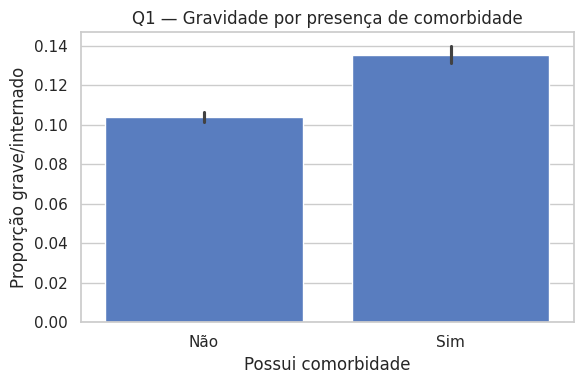

In [13]:
def taxa_por_grupo(df, grupo, alvo="grave_ou_internado"):
    g = df.groupby(grupo, observed=True)[alvo].agg(["mean", "count"])
    g["mean"] = (g["mean"] * 100).round(1)
    return g.rename(columns={"mean": "% grave/internado", "count": "n"})


q1 = taxa_por_grupo(df_int, "tem_comorbidade")
print(q1)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=df_int, x="tem_comorbidade", y="grave_ou_internado",
            errorbar=("ci", 95), ax=ax)
ax.set_ylabel("Proporção grave/internado")
ax.set_xlabel("Possui comorbidade")
ax.set_title("Q1 — Gravidade por presença de comorbidade")
ax.set_xticklabels(["Não", "Sim"])
plt.tight_layout(); plt.show()

### Q2 — Efeito dose-resposta (multimorbidade)
A chance de internação cresce monotonicamente com o número de comorbidades?

                % grave/internado      n
n_comorbidades                          
0                            10.4  54958
1                            12.9  20568
2                            15.9   4070
3                            22.1    385
4                            23.5     17
5                             0.0      2


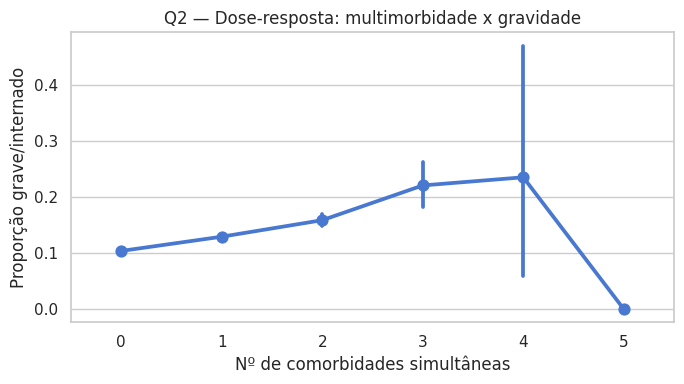

In [14]:
q2 = taxa_por_grupo(df_int, "n_comorbidades")
print(q2)

fig, ax = plt.subplots(figsize=(7, 4))
sns.pointplot(data=df_int, x="n_comorbidades", y="grave_ou_internado",
              errorbar=("ci", 95), ax=ax)
ax.set_xlabel("Nº de comorbidades simultâneas")
ax.set_ylabel("Proporção grave/internado")
ax.set_title("Q2 — Dose-resposta: multimorbidade x gravidade")
plt.tight_layout(); plt.show()

### Q3 — Moderação por idade e sexo
O efeito da comorbidade muda entre faixas etárias? (recupera a ideia demográfica original)

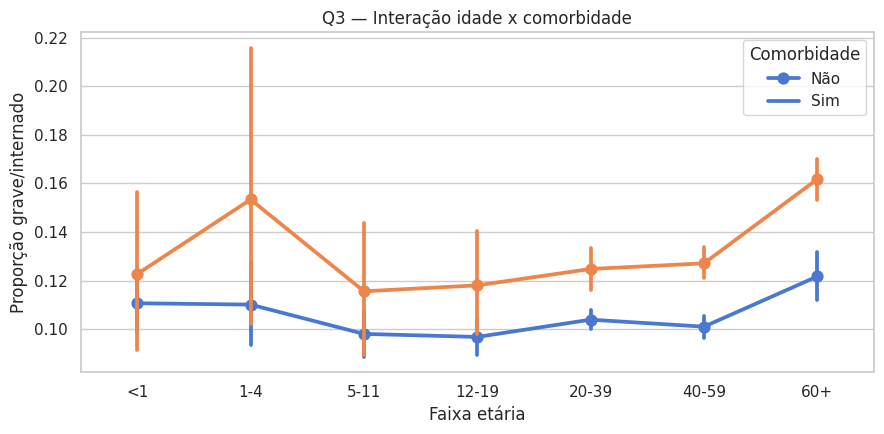

tem_comorbidade  False  True 
faixa_etaria                 
<1                11.1   12.3
1-4               11.0   15.3
5-11               9.8   11.6
12-19              9.7   11.8
20-39             10.4   12.5
40-59             10.1   12.7
60+               12.2   16.2


In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.pointplot(data=df_int, x="faixa_etaria", y="grave_ou_internado",
              hue="tem_comorbidade", errorbar=("ci", 95),
              order=["<1", "1-4", "5-11", "12-19", "20-39", "40-59", "60+"], ax=ax)
ax.set_xlabel("Faixa etária")
ax.set_ylabel("Proporção grave/internado")
ax.set_title("Q3 — Interação idade x comorbidade")
ax.legend(title="Comorbidade", labels=["Não", "Sim"])
plt.tight_layout(); plt.show()

# Tabela cruzada idade x comorbidade
tab_q3 = (df_int.groupby(["faixa_etaria", "tem_comorbidade"], observed=True)["grave_ou_internado"]
          .mean().mul(100).round(1).unstack())
print(tab_q3)

### Q4 — Assinatura por doença
O peso de **cada** comorbidade é igual entre dengue / chikungunya / zika / febre amarela?
Usamos a tabela-ponte (`dim_comorbidade`) cruzada com o alvo da fato.

doenca                chikungunya  dengue  febre_amarela  zika
comorbidade                                                   
diabetes                     14.4    13.5           14.5  15.7
doenca_acido_peptica         14.0    14.5           13.6  12.9
doenca_autoimune             13.0    14.9           12.4  15.9
doenca_hematologica          10.9    11.9           14.6  10.7
doenca_renal_cronica         12.9    13.5           14.5  13.9
hepatopatia                  14.1    14.6           16.1  15.4
hipertensao                  13.6    14.0           14.6  14.0


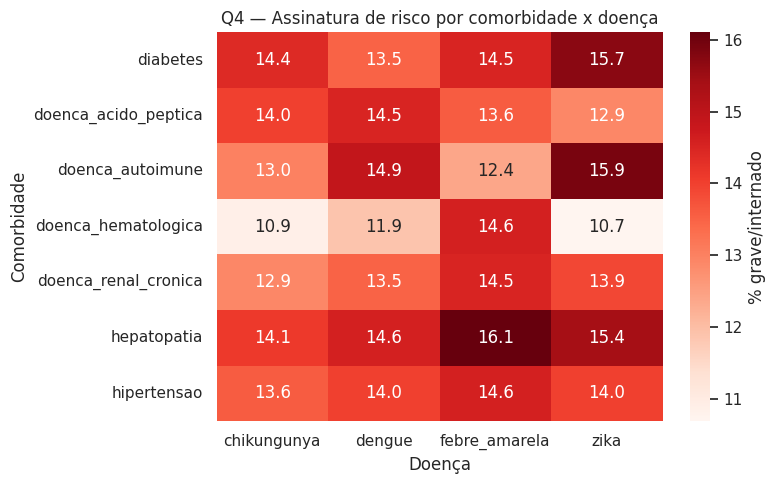

In [16]:
analise = dim_comorbidade.merge(
    fato_caso[["id_caso", "doenca", "grave_ou_internado"]], on="id_caso"
)
# % grave/internado entre quem TEM cada comorbidade, por doença
assinatura = (
    analise[analise["presente"]]
    .groupby(["doenca", "comorbidade"], observed=True)["grave_ou_internado"]
    .mean().mul(100).round(1).unstack(0)
)
print(assinatura)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(assinatura, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "% grave/internado"}, ax=ax)
ax.set_title("Q4 — Assinatura de risco por comorbidade x doença")
ax.set_xlabel("Doença"); ax.set_ylabel("Comorbidade")
plt.tight_layout(); plt.show()

### Q5 — Tempo até o atendimento (resgate do "atraso")
Pacientes com comorbidade demoram mais (ou menos) entre o início dos sintomas e a internação?

/tmp/ipykernel_615/2950347726.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Não", "Sim"])


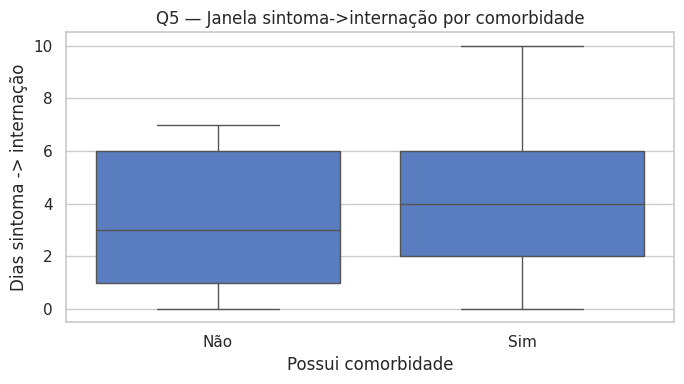

                  count  mean  50%
tem_comorbidade                   
False            5523.0  3.46  3.0
True             3202.0  3.80  4.0


In [17]:
sub = df_int.dropna(subset=["dias_sintoma_internacao"])
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=sub, x="tem_comorbidade", y="dias_sintoma_internacao", ax=ax)
ax.set_xlabel("Possui comorbidade"); ax.set_ylabel("Dias sintoma -> internação")
ax.set_xticklabels(["Não", "Sim"])
ax.set_title("Q5 — Janela sintoma->internação por comorbidade")
plt.tight_layout(); plt.show()

print(sub.groupby("tem_comorbidade")["dias_sintoma_internacao"].describe()[["count", "mean", "50%"]].round(2))

## 9. Inferência estatística — associação e tamanho de efeito

Visualização sugere; estatística confirma. Para cada comorbidade calculamos:
- **Qui-quadrado** de independência (comorbidade × desfecho grave);
- **Odds Ratio** com **intervalo de confiança 95%** (tamanho de efeito interpretável).

In [18]:
def odds_ratio_ic(df, comorb_col, alvo="grave_ou_internado"):
    """OR e IC95% (Woolf) para 'sim' vs 'nao' (ignora 'ignorado')."""
    d = df[df[comorb_col].isin(["sim", "nao"])]
    tabela = pd.crosstab(d[comorb_col], d[alvo])
    # garante orientação [linhas: nao,sim][colunas: False,True]
    tabela = tabela.reindex(index=["nao", "sim"], columns=[False, True]).fillna(0)
    a = tabela.loc["sim", True]; b = tabela.loc["sim", False]
    c = tabela.loc["nao", True]; d_ = tabela.loc["nao", False]
    # correção de Haldane se houver zero
    if 0 in (a, b, c, d_):
        a, b, c, d_ = a + .5, b + .5, c + .5, d_ + .5
    orr = (a * d_) / (b * c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d_)
    li, ls = np.exp(np.log(orr) - 1.96 * se), np.exp(np.log(orr) + 1.96 * se)
    chi2, p, _, _ = stats.chi2_contingency(tabela.values)
    return {"OR": round(orr, 2), "IC95%": f"[{li:.2f}; {ls:.2f}]",
            "p-valor": f"{p:.2e}", "n": int(tabela.values.sum())}


resultados = (
    pd.DataFrame({c: odds_ratio_ic(df_int, c) for c in COMORBIDADES.values()})
    .T.sort_values("OR", ascending=False)
)
resultados

,OR,IC95%,p-valor,n
hepatopatia,1.41,[1.25; 1.60],6.17e-08,65568
diabetes,1.37,[1.28; 1.47],7.28e-19,65670
hipertensao,1.33,[1.26; 1.41],3.19e-21,65567
doenca_autoimune,1.29,[1.13; 1.46],1.40e-04,65545
doenca_renal_cronica,1.26,[1.12; 1.41],1.01e-04,65542
doenca_acido_peptica,1.25,[1.13; 1.38],2.19e-05,65521
doenca_hematologica,1.06,[0.89; 1.25],5.63e-01,65328


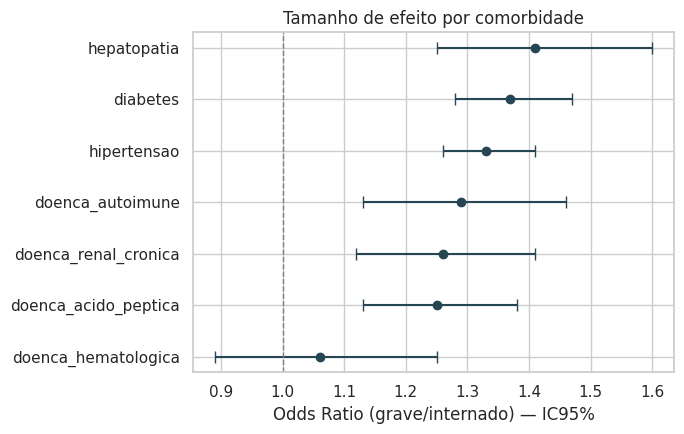

In [19]:
# Forest plot dos Odds Ratios
ors = pd.DataFrame({c: odds_ratio_ic(df_int, c) for c in COMORBIDADES.values()}).T
ors["OR_num"] = ors["OR"].astype(float)
ors["li"] = ors["IC95%"].str.extract(r"\[([\d.]+)").astype(float)
ors["ls"] = ors["IC95%"].str.extract(r";\s*([\d.]+)").astype(float)
ors = ors.sort_values("OR_num")

fig, ax = plt.subplots(figsize=(7, 4.5))
y = np.arange(len(ors))
ax.errorbar(ors["OR_num"], y,
            xerr=[ors["OR_num"] - ors["li"], ors["ls"] - ors["OR_num"]],
            fmt="o", color="#264653", capsize=4)
ax.axvline(1.0, color="grey", ls="--", lw=1)  # OR=1 -> sem efeito
ax.set_yticks(y); ax.set_yticklabels(ors.index)
ax.set_xlabel("Odds Ratio (grave/internado) — IC95%")
ax.set_title("Tamanho de efeito por comorbidade")
plt.tight_layout(); plt.show()

In [20]:
# Teste de tendência (Cochran-Armitage) para o efeito dose-resposta da Q2
from scipy.stats import chi2 as chi2_dist

def cochran_armitage(df, ordinal="n_comorbidades", alvo="grave_ou_internado"):
    t = pd.crosstab(df[ordinal], df[alvo]).reindex(columns=[False, True]).fillna(0)
    niveis = t.index.astype(float).values
    n_i = t.sum(axis=1).values
    casos = t[True].values
    N = n_i.sum(); R = casos.sum()
    p_bar = R / N
    num = (n_i * (casos / n_i - p_bar) * niveis).sum() ** 2
    den = p_bar * (1 - p_bar) * (n_i * (niveis - (n_i * niveis).sum() / N) ** 2).sum()
    z2 = num / den
    return z2, 1 - chi2_dist.cdf(z2, df=1)

z2, p = cochran_armitage(df_int)
print(f"Cochran-Armitage (tendência dose-resposta): estatística={z2:.2f}, p-valor={p:.2e}")
print("p < 0.05 indica tendência monotônica significativa entre nº de comorbidades e gravidade.")

Cochran-Armitage (tendência dose-resposta): estatística=224.46, p-valor=0.00e+00
p < 0.05 indica tendência monotônica significativa entre nº de comorbidades e gravidade.


## 10. Limitações e próximos passos

### Limitações
- **Qualidade do registro:** campos de comorbidade do SINAN têm muito `ignorado`/ausente (ver seção 5).
  O "ignorado" pode não ser aleatório — quem está mais grave talvez tenha o campo mais preenchido,
  gerando viés de registro. A análise de sensibilidade *complete-case* ajuda a dimensionar isso.
- **Causalidade:** associação ≠ causa. Confundidores (acesso ao serviço, gravidade prévia, idade) podem
  explicar parte do efeito → próximo passo é **regressão logística multivariada** ajustando por idade,
  sexo, UF e doença.
- **Comparabilidade entre fichas:** dengue/chikungunya compartilham ficha; **zika** e **febre amarela**
  têm fichas próprias — confirmar se os campos de comorbidade existem e têm os mesmos nomes antes de
  consolidar (febre amarela é doença mais grave e tem ficha mais detalhada).
- **Viabilidade do alvo:** óbito foi descartado como alvo justamente por raridade; a gravidade clínica
  é o substituto adequado, mas depende da qualidade do preenchimento de `CLASSI_FIN`.

### Próximos passos
1. **Regressão logística multivariada** (`statsmodels`) com OR ajustado por idade/sexo/UF/doença.
2. **Análise de sensibilidade** comparando "ignorado como categoria" vs *complete-case*.
3. Incorporar **IBGE** (população por município/faixa etária) para calcular **incidência** e padronizar taxas.
4. Materializar o modelo dimensional em **dbt + DuckDB** (Raw→Intermediate→Serving como models/staging/marts).
5. Modelo preditivo (ex.: árvore/boosting) de risco de internação como produto final do *serving*.